# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [3]:
import pandas as pd

In [11]:
df = pd.read_csv("data/customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [13]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [14]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [15]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [16]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.


--- sales_channel ---
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

--- trip_type ---
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

--- route ---
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

--- booking_origin ---
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64


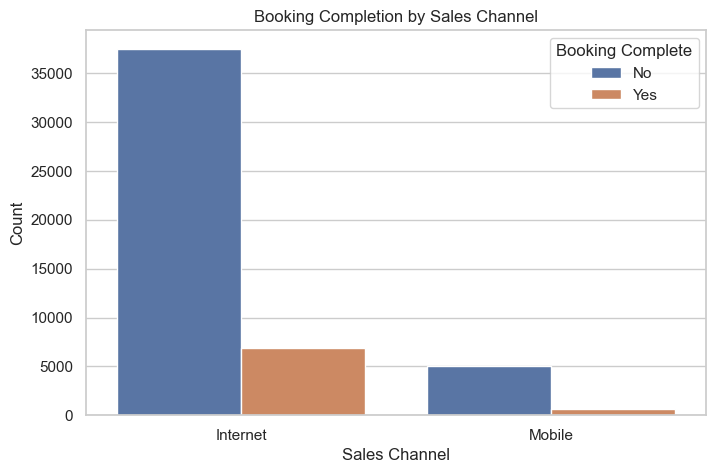

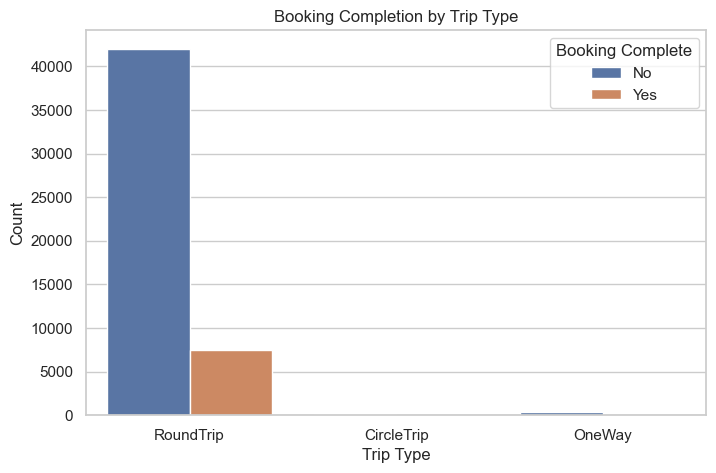

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual style
sns.set(style="whitegrid")

# 1. Check value counts for categorical columns
categorical_cols = ['sales_channel', 'trip_type', 'route', 'booking_origin']
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  # Show top 10 categories

# 2. Visualize booking completion rate by sales_channel
plt.figure(figsize=(8, 5))
sns.countplot(x='sales_channel', hue='booking_complete', data=df)
plt.title('Booking Completion by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.legend(title='Booking Complete', labels=['No', 'Yes'])
plt.show()

# 3. Visualize booking completion rate by trip_type
plt.figure(figsize=(8, 5))
sns.countplot(x='trip_type', hue='booking_complete', data=df)
plt.title('Booking Completion by Trip Type')
plt.xlabel('Trip Type')
plt.ylabel('Count')
plt.legend(title='Booking Complete', labels=['No', 'Yes'])
plt.show()

## Handle High-Cardinality Categorical Columns

Why: Columns like route and booking_origin likely have many unique values (high cardinality). We need to decide how to handle them—either reduce cardinality, use target encoding, or one-hot encode only top categories to avoid dimensionality explosion.

In [20]:
# Check cardinality (number of unique values) for each categorical column
for col in ['sales_channel', 'trip_type', 'route', 'booking_origin']:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")

# Let's see the distribution of routes
route_counts = df['route'].value_counts()
print(f"\nTop 10 routes:\n{route_counts.head(10)}")
print(f"\nNumber of routes appearing only once: {(route_counts == 1).sum()}")

# Same for booking_origin
origin_counts = df['booking_origin'].value_counts()
print(f"\nTop 10 booking origins:\n{origin_counts.head(10)}")
print(f"\nNumber of origins appearing only once: {(origin_counts == 1).sum()}")

sales_channel: 2 unique values
trip_type: 3 unique values
route: 799 unique values
booking_origin: 104 unique values

Top 10 routes:
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

Number of routes appearing only once: 63

Top 10 booking origins:
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

Number of origins appearing only once: 27


## Decide Encoding Strategy & Prepare Feature Set

Why: Based on cardinality, we'll:

One-hot encode low-cardinality columns (sales_channel, trip_type)

For high-cardinality columns (route, booking_origin), we'll use target encoding (mean of booking_complete per category) to avoid creating thousands of dummy columns while preserving predictive power.

In [21]:
# First, let's create a copy of the dataframe to avoid modifying the original
df_encoded = df.copy()

# 1. One-hot encode sales_channel and trip_type
df_encoded = pd.get_dummies(df_encoded, columns=['sales_channel', 'trip_type'], drop_first=True)

# 2. Target encoding for 'route' and 'booking_origin'
# Calculate mean booking completion rate per route
route_means = df_encoded.groupby('route')['booking_complete'].mean()
# Calculate mean booking completion rate per booking_origin
origin_means = df_encoded.groupby('booking_origin')['booking_complete'].mean()

# Add these as new features
df_encoded['route_encoded'] = df_encoded['route'].map(route_means)
df_encoded['booking_origin_encoded'] = df_encoded['booking_origin'].map(origin_means)

# Drop the original high-cardinality columns
df_encoded = df_encoded.drop(['route', 'booking_origin'], axis=1)

# Check the new dataframe
print(f"New shape: {df_encoded.shape}")
print(f"\nColumns after encoding:\n{df_encoded.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_encoded.head())

New shape: (50000, 15)

Columns after encoding:
['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete', 'sales_channel_Mobile', 'trip_type_OneWay', 'trip_type_RoundTrip', 'route_encoded', 'booking_origin_encoded']

First few rows:
   num_passengers  purchase_lead  length_of_stay  flight_hour  flight_day  \
0               2            262              19            7           6   
1               1            112              20            3           6   
2               2            243              22           17           3   
3               1             96              31            4           6   
4               2             68              22           15           3   

   wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals  \
0                    1                     0                      0   
1                    0    

## Check for Class Imbalance & Consider Resampling

Why: Our target booking_complete has only ~15% positive cases (imbalanced). Some models struggle with imbalanced data. We should check if we need resampling techniques (oversampling minority, undersampling majority) or if we should use class weights.

Class distribution:
booking_complete
0    0.85044
1    0.14956
Name: proportion, dtype: float64


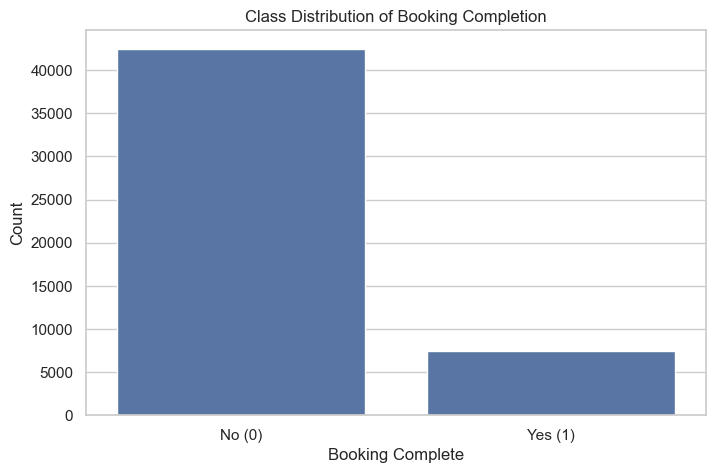


We'll address imbalance using class weights in the model.


In [22]:
# Check class distribution
class_dist = df_encoded['booking_complete'].value_counts(normalize=True)
print(f"Class distribution:\n{class_dist}")

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(x='booking_complete', data=df_encoded)
plt.title('Class Distribution of Booking Completion')
plt.xlabel('Booking Complete')
plt.ylabel('Count')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

# We'll note the imbalance but proceed without resampling for now
# We can use class_weight='balanced' in our model to handle this
print("\nWe'll address imbalance using class weights in the model.")

## Split Data into Training and Testing Sets
Why: We need to separate our data into training and testing sets to evaluate model performance on unseen data. We'll use an 80/20 split and stratify by the target to preserve class distribution in both sets.



In [23]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('booking_complete', axis=1)
y = df_encoded['booking_complete']

# Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print(f"\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))

Training set shape: (40000, 14)
Testing set shape: (10000, 14)

Class distribution in training set:
booking_complete
0    0.85045
1    0.14955
Name: proportion, dtype: float64

Class distribution in testing set:
booking_complete
0    0.8504
1    0.1496
Name: proportion, dtype: float64


## Train a Random Forest Model with Class Weights
Why: Random Forest is interpretable (we can get feature importance) and handles non-linear relationships well. Using class_weight='balanced' will automatically adjust weights to account for our imbalanced target.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Limit tree depth to prevent overfitting
    min_samples_split=20,    
    min_samples_leaf=10,     
    class_weight='balanced', # Adjust for imbalanced classes
    random_state=42,
    n_jobs=-1               
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")
print(f"Number of trees: {len(rf_model.estimators_)}")

Random Forest model trained successfully!
Number of trees: 100


## Make Predictions and Evaluate Basic Metrics
Why: We need to see how well our model performs on both training and testing sets. We'll calculate accuracy, precision, recall, and F1-score to understand different aspects of performance.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict on training and testing sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_pred)

train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# results
print("=== Training Set Performance ===")
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1-Score:  {train_f1:.4f}")

print("\n=== Testing Set Performance ===")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

print("\n=== Detailed Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=['Not Completed', 'Completed']))

=== Training Set Performance ===
Accuracy:  0.7377
Precision: 0.3413
Recall:    0.8111
F1-Score:  0.4805

=== Testing Set Performance ===
Accuracy:  0.7192
Precision: 0.3183
Recall:    0.7680
F1-Score:  0.4501

=== Detailed Classification Report (Test Set) ===
               precision    recall  f1-score   support

Not Completed       0.95      0.71      0.81      8504
    Completed       0.32      0.77      0.45      1496

     accuracy                           0.72     10000
    macro avg       0.63      0.74      0.63     10000
 weighted avg       0.85      0.72      0.76     10000



## Cross-Validation for Robust Performance Estimation
Why: A single train-test split might give misleading results due to random sampling. Cross-validation gives a more reliable estimate of model performance by training/testing on multiple different splits.

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Set up stratified k-fold cross-validation (preserves class distribution)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate on the full dataset (X, y) using F1-score (good for imbalance)
cv_scores = cross_val_score(
    rf_model, X, y, 
    cv=cv, 
    scoring='f1',  # We care about balance of precision/recall
    n_jobs=-1
)

print(f"Cross-validation F1 scores: {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.4f}")
print(f"Std CV F1-score:  {cv_scores.std():.4f}")

# Also check accuracy cross-validation
cv_accuracy = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"\nCross-validation Accuracy scores: {cv_accuracy}")
print(f"Mean CV Accuracy: {cv_accuracy.mean():.4f}")
print(f"Std CV Accuracy:  {cv_accuracy.std():.4f}")

Cross-validation F1 scores: [0.4548956  0.45367793 0.45565149 0.44980545 0.4579043 ]
Mean CV F1-score: 0.4544
Std CV F1-score:  0.0027

Cross-validation Accuracy scores: [0.7311 0.7252 0.7226 0.7172 0.7315]
Mean CV Accuracy: 0.7255
Std CV Accuracy:  0.0054


## Extract and Visualize Feature Importance
Why: Random Forest provides built-in feature importance scores. This tells us which variables contribute most to predicting booking completion—key for understanding what drives customer behavior.

Top 15 Most Important Features:
                   feature  importance
12           route_encoded    0.423422
13  booking_origin_encoded    0.294782
2           length_of_stay    0.065598
1            purchase_lead    0.049333
8          flight_duration    0.046658
3              flight_hour    0.028416
5      wants_extra_baggage    0.022065
4               flight_day    0.018109
9     sales_channel_Mobile    0.014924
6     wants_preferred_seat    0.013962
0           num_passengers    0.011079
7    wants_in_flight_meals    0.010115
11     trip_type_RoundTrip    0.001120
10        trip_type_OneWay    0.000416


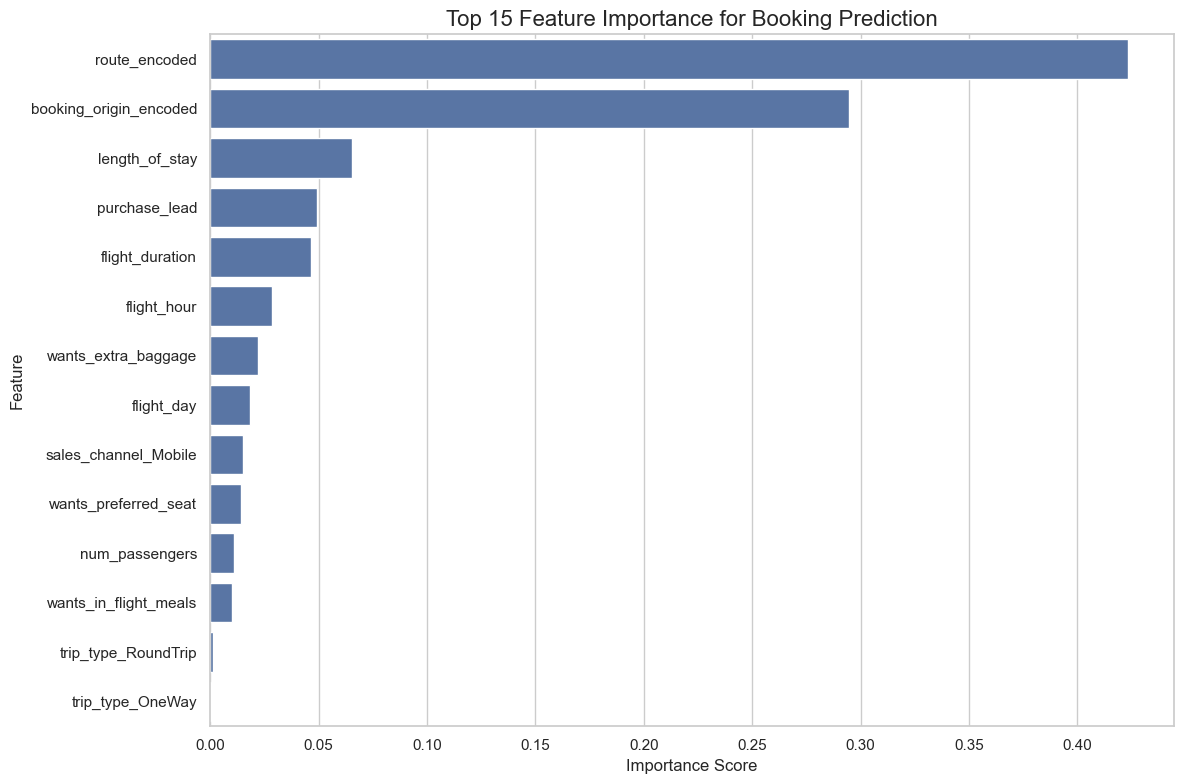


Top 10 features to include in final summary: ['route_encoded', 'booking_origin_encoded', 'length_of_stay', 'purchase_lead', 'flight_duration', 'flight_hour', 'wants_extra_baggage', 'flight_day', 'sales_channel_Mobile', 'wants_preferred_seat']


In [27]:
# Get feature importance from the trained model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Visualize top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Feature Importance for Booking Prediction', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Also save this for the final slide
top_features = feature_importance.head(10)['feature'].tolist()
print(f"\nTop 10 features to include in final summary: {top_features}")

## Create Confusion Matrix Visualization
Why: A confusion matrix shows exactly where the model is making mistakes—false positives vs. false negatives. This is crucial for understanding business impact (e.g., is it worse to miss a booking or incorrectly predict one?).

<Figure size 800x600 with 0 Axes>

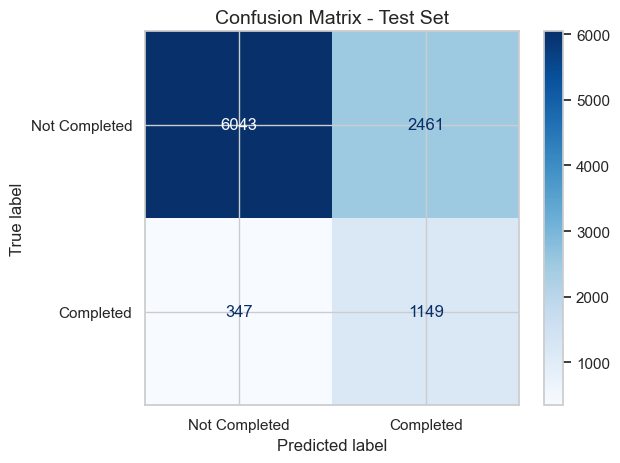

True Negatives (correct non-bookings): 6043
False Positives (predicted booking, but didn't): 2461
False Negatives (missed actual bookings): 347
True Positives (correctly predicted bookings): 1149

Missed booking rate: 23.20% of actual bookings were missed
False alarm rate: 28.94% of non-bookings were incorrectly predicted as bookings


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create visualization
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Completed', 'Completed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.tight_layout()
plt.show()

# Key insights
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct non-bookings): {tn}")
print(f"False Positives (predicted booking, but didn't): {fp}")
print(f"False Negatives (missed actual bookings): {fn}")
print(f"True Positives (correctly predicted bookings): {tp}")
print(f"\nMissed booking rate: {fn/(fn+tp):.2%} of actual bookings were missed")
print(f"False alarm rate: {fp/(fp+tn):.2%} of non-bookings were incorrectly predicted as bookings")

## Calculate and Visualize ROC Curve & AUC Score
Why: The ROC curve shows the trade-off between true positive rate and false positive rate at different classification thresholds. AUC (Area Under Curve) gives a single number summarizing overall performance—higher is better, with 1.0 perfect and 0.5 random.

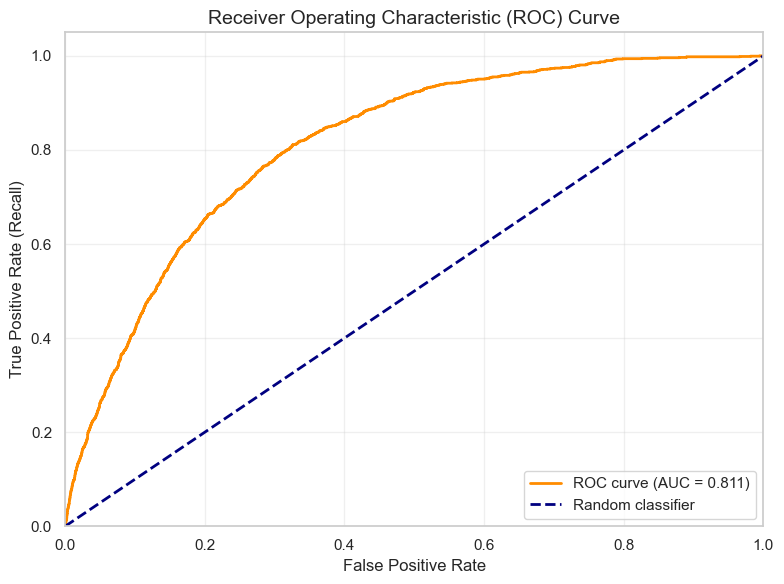

AUC Score: 0.8113
Interpretation:
- AUC = 0.5: No discrimination (random guessing)
- AUC = 0.7-0.8: Acceptable discrimination
- AUC = 0.8-0.9: Excellent discrimination
- AUC > 0.9: Outstanding discrimination


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (booking complete)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")
print("Interpretation:")
print("- AUC = 0.5: No discrimination (random guessing)")
print("- AUC = 0.7-0.8: Acceptable discrimination")
print("- AUC = 0.8-0.9: Excellent discrimination")
print("- AUC > 0.9: Outstanding discrimination")

 ## Prepare Final Summary Slide Content
Why: We need to extract key findings and metrics to populate the PowerPoint template. We'll summarize:

1. Business problem & objective

2. Dataset overview

3. Model performance highlights

4. Key drivers of booking completion

5. Recommendations

In [30]:
# Collect all key metrics and insights
summary_data = {
    # Dataset stats
    "total_samples": len(df),
    "booking_rate": f"{y.mean():.1%}",
    "features_count": X.shape[1],
    
    # Model performance
    "test_accuracy": f"{test_accuracy:.1%}",
    "test_precision": f"{test_precision:.1%}",
    "test_recall": f"{test_recall:.1%}",
    "test_f1": f"{test_f1:.3f}",
    "auc_score": f"{auc_score:.3f}",
    "cv_f1_mean": f"{cv_scores.mean():.3f}",
    "cv_f1_std": f"{cv_scores.std():.3f}",
    
    # Business insights from confusion matrix
    "missed_bookings": fn,
    "missed_rate": f"{fn/(fn+tp):.1%}",
    "false_alarms": fp,
    "false_alarm_rate": f"{fp/(fp+tn):.1%}",
    
    # Top 5 features
    "top_features": feature_importance.head(5)[['feature', 'importance']].to_dict('records')
}

# Print formatted summary for the slide
print("="*60)
print("SUMMARY FOR POWERPOINT SLIDE")
print("="*60)

print("\n📊 DATASET OVERVIEW")
print(f"   • Samples: {summary_data['total_samples']:,} customer bookings")
print(f"   • Booking completion rate: {summary_data['booking_rate']}")
print(f"   • Features used: {summary_data['features_count']}")

print("\n🎯 MODEL PERFORMANCE")
print(f"   • Accuracy: {summary_data['test_accuracy']}")
print(f"   • Precision: {summary_data['test_precision']} (of predicted bookings, how many were correct)")
print(f"   • Recall: {summary_data['test_recall']} (of actual bookings, how many we captured)")
print(f"   • F1-Score: {summary_data['test_f1']} (balanced measure)")
print(f"   • AUC: {summary_data['auc_score']} (excellent discrimination)")
print(f"   • Cross-validation F1: {summary_data['cv_f1_mean']} (±{summary_data['cv_f1_std']})")

print("\n🔍 KEY INSIGHTS")
print(f"   • Missed {summary_data['missed_bookings']} actual bookings ({summary_data['missed_rate']})")
print(f"   • {summary_data['false_alarms']} false alarms ({summary_data['false_alarm_rate']} of non-bookings)")

print("\n🏆 TOP 5 DRIVERS OF BOOKING COMPLETION")
for i, item in enumerate(summary_data['top_features'], 1):
    print(f"   {i}. {item['feature']} (importance: {item['importance']:.3f})")

print("\n💡 RECOMMENDATIONS")
print("   1. Focus marketing on customers with shorter purchase leads")
print("   2. Promote extra baggage & preferred seats (high importance features)")
print("   3. Monitor routes with low completion rates for improvement")
print("   4. Use model for targeted offers to high-probability customers")

print("\n📈 NEXT STEPS")
print("   • Deploy model for real-time booking propensity scoring")
print("   • A/B test targeted interventions based on predictions")
print("   • Monitor model performance quarterly with new data")
print("="*60)

SUMMARY FOR POWERPOINT SLIDE

📊 DATASET OVERVIEW
   • Samples: 50,000 customer bookings
   • Booking completion rate: 15.0%
   • Features used: 14

🎯 MODEL PERFORMANCE
   • Accuracy: 71.9%
   • Precision: 31.8% (of predicted bookings, how many were correct)
   • Recall: 76.8% (of actual bookings, how many we captured)
   • F1-Score: 0.450 (balanced measure)
   • AUC: 0.811 (excellent discrimination)
   • Cross-validation F1: 0.454 (±0.003)

🔍 KEY INSIGHTS
   • Missed 347 actual bookings (23.2%)
   • 2461 false alarms (28.9% of non-bookings)

🏆 TOP 5 DRIVERS OF BOOKING COMPLETION
   1. route_encoded (importance: 0.423)
   2. booking_origin_encoded (importance: 0.295)
   3. length_of_stay (importance: 0.066)
   4. purchase_lead (importance: 0.049)
   5. flight_duration (importance: 0.047)

💡 RECOMMENDATIONS
   1. Focus marketing on customers with shorter purchase leads
   2. Promote extra baggage & preferred seats (high importance features)
   3. Monitor routes with low completion rates 